In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# XGBoost model:
### Packages Importing, downloading data from yahoo finances for example stock:

In [ ]:
# מייבאים את המודול yfinance להורדת נתוני מניות
import yfinance as yf
# מייבאים את הפונקציה לחלק את הנתונים לאימונים ולבדיקות
from sklearn.model_selection import train_test_split
# מייבאים את מודל XGBoost לרגרסיה
from xgboost import XGBRegressor
# מייבאים את matplotlib לצורך יצירת גרפים
import matplotlib.pyplot as plt
# מייבאים את StandardScaler לנרמול הנתונים
from sklearn.preprocessing import StandardScaler
# מייבאים את pandas לצורך ניהול מסגרות נתונים
import pandas as pd
# מייבאים את numpy לצורך עבודה עם מערכים
import numpy as np
# מייבאים את matplotlib.dates לצורך עיצוב תאריכים בגרפים
import matplotlib.dates as mdates
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# # רשימת הסימולים של המניות (תוקנה, הוסר מחרוזת ריקה)
df_tickers = pd.read_csv("/content/drive/Shareddrives/capstone project-stock market robo-advisor/symbols_Israel.csv")
tickers = df_tickers["0"].tolist()

# # הורדת נתוני המניות בין התאריכים 01-01-2020 עד 31-12-2024
data = yf.download(tickers, start="2020-01-01", end="2024-12-31", auto_adjust=False)['Adj Close']
data

[**********************91%*******************    ]  462 of 510 completedERROR:yfinance:Could not get exchangeTimezoneName for ticker '???.TA' reason: 'chart'
[*********************100%***********************]  510 of 510 completed
ERROR:yfinance:
15 Failed downloads:
ERROR:yfinance:['ARAD.TA', 'UNCR.TA', 'INTO.TA', 'YAAC.TA', 'AICS-M.TA', 'ECPA-M.TA', 'INFR-M.TA', 'LVPR.TA', 'PMCN.TA', 'CNZN.TA', 'HDHA.TA', 'ENDY.TA', 'GLTC.TA', '???.TA', 'UNVO.TA']: YFTzMissingError('possibly delisted; no timezone found')


Ticker,???.TA,ABRA.TA,ACCL.TA,ACKR.TA,ACRO.TA,ADGR.TA,AFHL.TA,AFPR.TA,AFRE.TA,AICS-M.TA,...,XTLB.TA,YAAC.TA,YBOX.TA,YBRD.TA,YHNF.TA,ZMH.TA,ZNKL.TA,ZOOZ.TA,ZPRS.TA,ZUR.TA
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,NaN,209.965805,50.000000,NaN,NaN,848.439148,14554.273438,14411.866211,9918.053711,NaN,...,4.6,NaN,72.882301,11060.000000,17561.455078,1961.399292,1872.455444,NaN,NaN,1409.733276
2020-01-02,NaN,218.123596,54.200001,NaN,NaN,846.642395,14344.500977,14481.537109,9989.909180,NaN,...,4.8,NaN,72.386497,10850.000000,17711.214844,1963.395386,1954.170044,NaN,NaN,1426.694092
2020-01-05,NaN,212.685104,51.900002,NaN,NaN,846.043457,13914.963867,14332.243164,10039.806641,NaN,...,4.6,NaN,71.692398,10980.000000,17711.214844,1960.400635,1958.156006,NaN,NaN,1438.666382
2020-01-06,NaN,202.099396,33.299999,NaN,NaN,837.060059,13435.483398,14192.901367,9833.222656,NaN,...,4.5,NaN,71.196602,11020.000000,17671.277344,1970.382446,1983.068848,NaN,NaN,1418.712524
2020-01-07,NaN,210.742798,51.400002,NaN,NaN,835.363281,13525.385742,14441.725586,9887.115234,NaN,...,4.5,NaN,73.774696,10790.000000,17870.953125,1958.404053,1917.298950,NaN,NaN,1389.779541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,NaN,291.399994,132.199997,838.788025,5540.930664,581.400024,18380.000000,16860.000000,27777.767578,NaN,...,5.9,NaN,110.199997,912.099976,23176.634766,3853.834961,4203.263672,970.200012,1710.0,840.799988
2024-12-25,NaN,299.299988,130.600006,847.085876,5543.930664,580.900024,17510.000000,16650.000000,27937.755859,NaN,...,6.5,NaN,109.800003,990.200012,23016.658203,3827.836182,4177.268555,950.299988,1629.0,843.700012
2024-12-26,NaN,296.299988,130.699997,833.989258,5431.932129,578.400024,17960.000000,16730.000000,27197.814453,NaN,...,6.3,NaN,109.199997,817.400024,22926.669922,3747.839600,4146.273926,926.099976,1583.0,848.599976


In [ ]:
# פונקציה לציור גרף המציג את המחירים בפועל מול המחירים החזויים
def plot_actual_vs_predicted(data, y_test, pred, model_name='Model'):
    plt.figure(figsize=(16, 8))  # הגדרת גודל הגרף

    # ודא שהאינדקס של הנתונים הוא בפורמט תאריך
    data.index = pd.to_datetime(data.index)

    # ציור המחירים בפועל (בכחול) והמחירים החזויים (באדום)
    plt.plot(data.index[-len(y_test):], y_test, label='Actual', color='blue', linewidth=2)
    plt.plot(data.index[-len(y_test):], pred, label='Predicted', color='red', linewidth=2)
    plt.fill_between(data.index[-len(y_test):], y_test, pred, color='gray', alpha=0.3)  # אזור הצללה בין תחזית למחירים בפועל

    plt.xlabel('Date', fontsize=14)  # תווית ציר X
    plt.ylabel('Price', fontsize=14)  # תווית ציר Y
    plt.title(f'{model_name}: Actual vs Predicted Prices Over Time', fontsize=16)  # כותרת הגרף
    plt.legend(fontsize=12)  # הוספת אגדה

    # עיצוב ציר ה-X לתצוגת תאריכים
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.gcf().autofmt_xdate()  # סידור אוטומטי של התאריכים
    plt.tight_layout()  # התאמת הגרף לחלון התצוגה
    plt.grid(True, linestyle='--', alpha=0.7)  # הוספת רשת
    plt.show()

# מעדכנים את רשימת המניות לאחר הורדת מניות עם פחות מ 100 ימים בדאטא
tickers = data.columns.tolist()
# יצירת ממוצעים נעים (Rolling windows) עם טיפול בנתוני NaN
for window in [2, 5, 10, 20, 60]:  # עבור חלונות של 2, 5, 10, 20 ו-60 ימים
    for ticker in tickers:  # עבור כל סמל במניות
        # ממוצע נע
        data[f'{ticker}_rolling_{window}'] = data[ticker].rolling(window=window).mean().fillna(method='ffill').fillna(method='bfill')
        # סטיית תקן נעה
        data[f'{ticker}_rollingSTD_{window}'] = data[ticker].rolling(window=window).std().fillna(method='ffill').fillna(method='bfill')
        # חציון נע
        data[f'{ticker}_rollingMedian_{window}'] = data[ticker].rolling(window=window).median().fillna(method='ffill').fillna(method='bfill')

# # הוספת ממוצע נע אקספוננציאלי עבור החלונות הבאים
# for window in [20, 50, 100, 200]:
#     for ticker in tickers:
#         data[f'{ticker}_ema_{window}'] = data[ticker].ewm(span=window, adjust=False).mean()


# מילוי ערכי NaN עם הערך הקודם או הבא
data.fillna(method='bfill', inplace=True)
data.fillna(method='ffill', inplace=True)


Streaming output truncated to the last 5000 lines.
<ipython-input-3-d326ba6432c8>:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[f'{ticker}_rollingMedian_{window}'] = data[ticker].rolling(window=window).median().fillna(method='ffill').fillna(method='bfill')
<ipython-input-3-d326ba6432c8>:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'{ticker}_rollingMedian_{window}'] = data[ticker].rolling(window=window).median().fillna(method='ffill').fillna(method='bfill')
<ipython-input-3-d326ba6432c8>:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[f'{ticker}_rolling_{wi

In [ ]:
data.shape

(1229, 8160)

## 🚀 XGBoost-Based Stock Price Prediction & Forecasting

This notebook applies **XGBoost regression** to predict and forecast the prices of individual TASE-listed stocks using the price histories of other stocks as predictive features. It evaluates model performance and outputs 30-day forward predictions.

---

### 🎯 Objective

For each target stock:
- Use historical prices  as independent variables (features).
- Predict the target stock’s future values using **XGBoost**.
- Evaluate prediction accuracy using:
  - R-squared (R²)
  - MAE (Mean Absolute Error)
  - MSE (Mean Squared Error)
- Forecast **30 future values** based on the most recent 30-day input window.

---

### 📂 Input

- `data`: A DataFrame containing multiple stock price series.
  - Each column = one stock (e.g., `ARAN.TA`, `TEVA.TA`).
- You choose a target stock by setting `name_of_stock = "XYZ.TA"`.

---

### 🔄 Pipeline Breakdown

1. **Feature Engineering**:
   - Drop the target column from `data`.
   - Apply `StandardScaler` to standardize features.

2. **Train-Test Split**:
   - Chronologically split (no shuffling!) into train/test sets (80/20 split).
   - Ensures test set follows training in time — important for time series.

3. **Model Definition**:
   - XGBoost Regressor:
     - `n_estimators=100`
     - `learning_rate=0.05`
     - `max_depth=6`
     - `random_state=42`

4. **Evaluation Metrics**:
   - R²: How well the model explains variance in the test set.
   - MAE: Average error magnitude.
   - MSE: Penalizes large errors more than MAE.

5. **Forecasting Future Values**:
   - Use the last 30 rows of scaled features (`X_last_30`) as future input.
   - Predict the next 30 days (`Day_1`, ..., `Day_30`) with the trained model.

---

### ✅ Output Structure

The script constructs a single-row `DataFrame` with:

| Stock   | R-squared | MAE | MSE | Day_1 | Day_2 | ... | Day_30 | y_test (JSON) | y_pred (JSON) |
|---------|-----------|-----|-----|--------|--------|-----|---------|----------------|-----------------|
| ARAN.TA | 0.87      | 2.03| 5.34| 492.12 | 491.98 | ... | 502.66 | [real values]  | [predictions]  |

- `y_test` and `y_pred` are serialized as JSON for full traceability.




Processing stock: ???.TA
An error occurred while processing stock ???.TA: [08:00:56] /workspace/src/data/data.cc:514: Check failed: valid: Label contains NaN, infinity or a value too large.
Stack trace:
  [bt] (0) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x25c1ac) [0x7ed69e45c1ac]
  [bt] (1) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x4e2229) [0x7ed69e6e2229]
  [bt] (2) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(+0x4e3a60) [0x7ed69e6e3a60]
  [bt] (3) /usr/local/lib/python3.11/dist-packages/xgboost/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0xb2) [0x7ed69e363522]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7ed70cbb2e2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7ed70cbaf493]
  [bt] (6) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0xa4d8) [0x7ed70ce134d8]
  [bt] (7) /usr/lib/python3.11/lib-dynload/_ctypes.cpython-311-x86_64-linux-gnu.so(+0x9c8e) [0x7ed70c

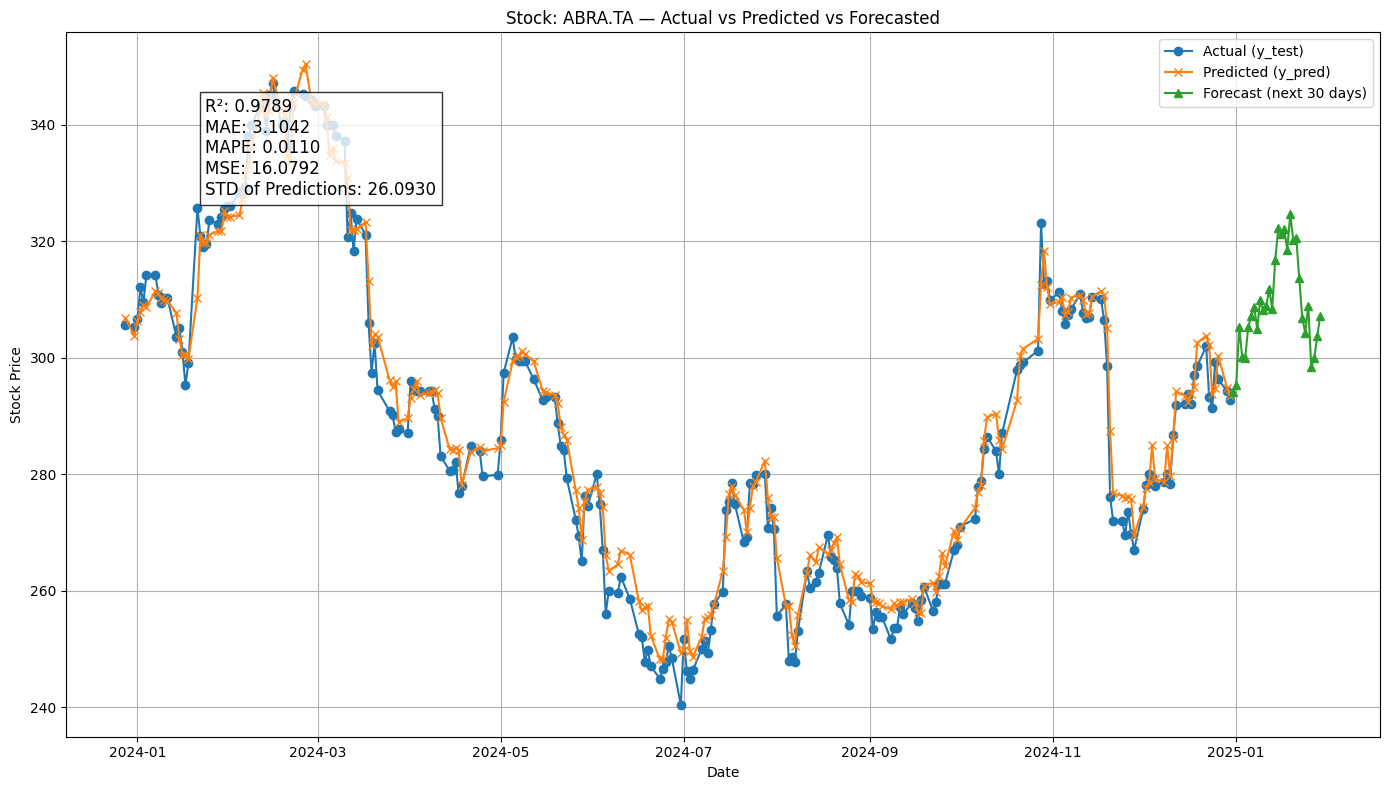

Processing stock: ACCL.TA
✅ XGBoost model for ACCL.TA saved to: /content/drive/Shareddrives/capstone project-stock market robo-advisor/XGBoost models/ACCL_TA_XGBoost_model.pkl
Metrics for stock: ACCL.TA
R-squared (R²): 0.9692
Mean Absolute Error (MAE): 2.8716
Mean Absolute Percentage Error (MAE): 0.0263
Mean Squared Error (MSE): 14.9679
Standard Deviation of Predictions: 20.3297


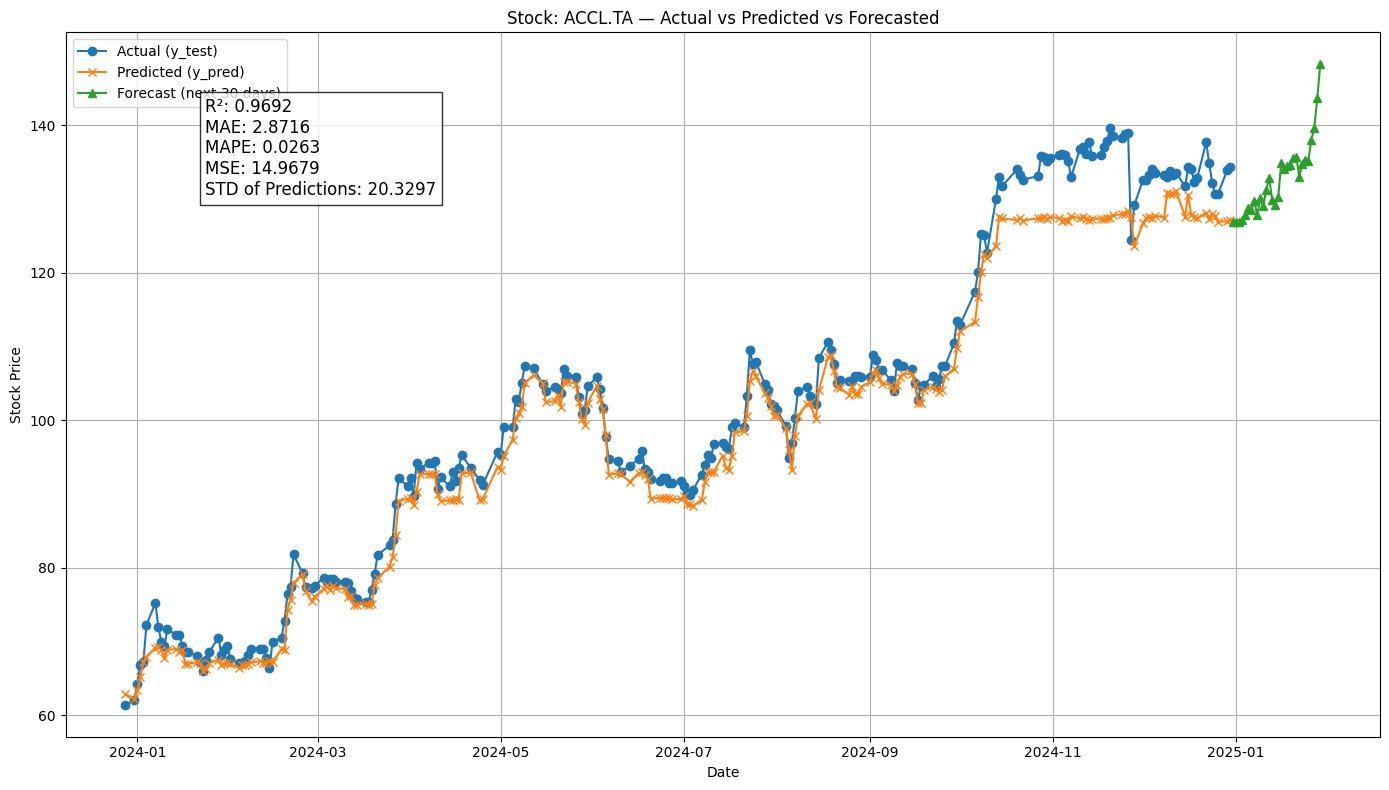

Processing stock: ACKR.TA
✅ XGBoost model for ACKR.TA saved to: /content/drive/Shareddrives/capstone project-stock market robo-advisor/XGBoost models/ACKR_TA_XGBoost_model.pkl
Metrics for stock: ACKR.TA
R-squared (R²): 0.2708
Mean Absolute Error (MAE): 41.2444
Mean Absolute Percentage Error (MAE): 0.0599
Mean Squared Error (MSE): 6794.9066
Standard Deviation of Predictions: 32.5331


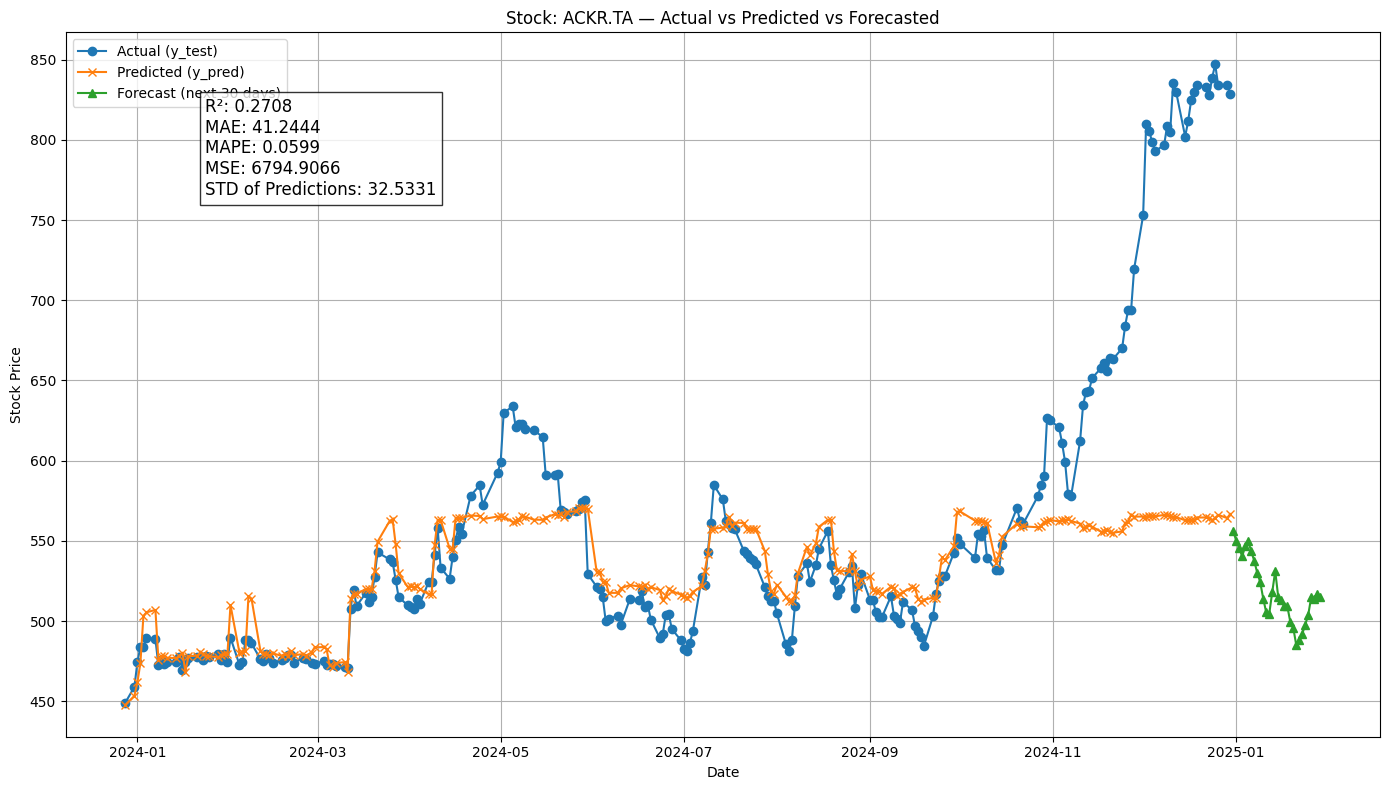

Processing stock: ACRO.TA


In [ ]:
import os
import json
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
# ignore warnings:
import warnings
warnings.filterwarnings('ignore')

# Define the output CSV file
output_csv_path = "model_XGBoost_metrics_and_predictions.csv"

# Get the list of stocks

###### Change here the number of stocks ######
stocks = data.columns

# Predefine the columns
base_columns = ['Stock', 'R-squared', 'MAE', 'MSE', 'MAPE'] + [f"Day_{i+1}" for i in range(30)] + ["y_test", "y_pred"]

# Initialize the empty metrics DataFrame
metrics_df = pd.DataFrame(columns=base_columns)
for ticker in tickers:

    print(f"Processing stock: {ticker}")

    try:
        # Normalize independent variables (X), excluding the target stock
        scaler_X = StandardScaler()
        X_scaled = pd.DataFrame(scaler_X.fit_transform(data.drop(columns=[ticker])),
                                columns=data.columns.drop(ticker),
                                index=data.index)

        # Define the target variable
        y = data[ticker]

        # Split data into training and testing sets (chronological order)
        X_train, X_test, y_train, y_test, train_dates, test_dates = train_test_split(
            X_scaled, y, X_scaled.index, test_size=0.2, random_state=42, shuffle=False)

        # Train the XGBoost model
        model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
        model.fit(X_train, y_train)

        # Predict on test data
        y_pred = model.predict(X_test)

        # Calculate Metrics
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        # Prepare data for the last 30 days
        X_last_30 = X_scaled.iloc[-30:].copy()
        X_scaled = X_scaled.iloc[:-30]

        # Predict future values for the next 30 days

        # Simulate forecast path from last predicted price
        future_predictions = [y_pred[-1]]  # Start from last known prediction

        for _ in range(30):
            # Compute percent changes from test predictions & future forecasts
            pct_changes = pd.Series(y_pred).pct_change().dropna()
            mean_pct_change = pct_changes.mean()
            std_pct_change = pct_changes.std()
            sampled_pct_change = np.random.normal(loc=mean_pct_change, scale=std_pct_change)
            new_forecast = future_predictions[-1] * (1 + sampled_pct_change)
            future_predictions.append(new_forecast)
            y_pred.append(new_forecast)

        y_pred = y_pred[:-30]
        # Strip the first value (initial known point) to get only new forecasts
        y_future_pred = future_predictions[1:]

        # Prepare columns for future predictions (Day_1, Day_2, ..., Day_30)
        prediction_columns = {f"Day_{i+1}": y_future_pred[i] for i in range(len(y_future_pred))}

        # Create a single row of data for the stock
        metrics_data = {
            # "Stock_Number": stock_number_offset + i - num_skip,  # Add stock number
            "Stock": ticker,
            "R-squared": r2,
            "MAE": mae,
            "MSE": mse,
            "MAPE": mape,
            **prediction_columns,  # Add the dynamic prediction columns
            "y_test": json.dumps(y_test.tolist()),  # Serialize y_test as a JSON string
            "y_pred": json.dumps(y_pred.tolist())   # Serialize y_pred as a JSON string
        }

        metrics_df_temp = pd.DataFrame([metrics_data])
        metrics_df = pd.concat([metrics_df, metrics_df_temp], ignore_index=True)

        # Define path
        os.makedirs("/content/drive/Shareddrives/capstone project-stock market robo-advisor/XGBoost models", exist_ok=True)

        model_path = f"/content/drive/Shareddrives/capstone project-stock market robo-advisor/XGBoost models/{ticker.replace('.', '_')}_XGBoost_model.pkl"

        # Save XGBoost model with pickle
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)

        print(f"✅ XGBoost model for {ticker} saved to: {model_path}")

        # Calculate standard deviation of predictions
        std_pred = np.std(y_pred)

        # Print all metrics
        print(f"Metrics for stock: {ticker}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"Mean Absolute Percentage Error (MAE): {mape:.4f}")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Standard Deviation of Predictions: {std_pred:.4f}")

        # Create a timeline for plotting
        # - y_test and y_pred follow the test_dates
        # - y_future_pred follows the 30 days after the last date

        test_dates = pd.Series(test_dates)

        future_dates = pd.date_range(start=test_dates.iloc[-1] + pd.Timedelta(days=1), periods=30, freq='D')

        # Plot
        plt.figure(figsize=(14, 8))

        # Plot actual test values
        plt.plot(test_dates, y_test.values, label='Actual (y_test)', marker='o')

        # Plot predicted test values
        plt.plot(test_dates, y_pred, label='Predicted (y_pred)', marker='x')

        # Plot future forecast
        plt.plot(future_dates, y_future_pred, label='Forecast (next 30 days)', marker='^')

        plt.title(f"Stock: {ticker} — Actual vs Predicted vs Forecasted")
        plt.xlabel('Date')
        plt.ylabel('Stock Price')
        plt.legend()
        plt.grid(True)

        # Annotate metrics on the plot
        metric_text = (f"R²: {r2:.4f}\n"
                      f"MAE: {mae:.4f}\n"
                      f"MAPE: {mape:.4f}\n"
                      f"MSE: {mse:.4f}\n"
                      f"STD of Predictions: {std_pred:.4f}")
        plt.gcf().text(0.15, 0.75, metric_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

        plt.tight_layout()
        plt.show()

        # # Append to CSV if it exists, otherwise create a new file
        # if os.path.exists(output_csv_path):
        #     existing_df = pd.read_csv(output_csv_path)
        #     updated_df = pd.concat([existing_df, metrics_df], ignore_index=True)
        #     updated_df.to_csv(output_csv_path, index=False)
        # else:
        #     metrics_df.to_csv(output_csv_path, index=False)

        # print(f"Metrics and future predictions for {ticker} saved to {output_csv_path}")

    except Exception as e:
        # Log the error and continue with the next stock
        print(f"An error occurred while processing stock {ticker}: {e}")
        # num_skip += 1


### Plotting Results:

In [ ]:
metrics_df